In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
from constants import FEATURES


# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd
from signal_region import get_SR_CR_cut, compute_sr_stats
from correct_systematic_error import get_histograms, get_quantiles_with_weights

metadata = TrainingInfo.load_metadata()

In [3]:
from tqdm import tqdm


def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

sig_level = 0.05
SR_size = 0.2
SB_size = 0.15

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                     "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                     return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results = {}
results_df = {}

for correction_width in [0.1, 0.25, 0.5, 1, 1.6, 2]:
    results[correction_width] = []
    
    for hash_ in tqdm(hashes):
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
        signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
        SR_size = CR_fvt_tinfo.hparams["signal_region"]["4b_in_SR"]
        SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
        
        smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
            
        
        if f"correction_{correction_width}_SB_size={SB_size}" in CR_fvt_tinfo.aux_info:
            correction_results = CR_fvt_tinfo.aux_info[f"correction_{correction_width}_SB_size={SB_size}"]
        else:
            continue
            
        results[correction_width].append({
            "seed": seed,
            "signal_ratio": signal_ratio,
            "SR_size": SR_size,
            "noise_scale": noise_scale,
            "theta_SB_mean": correction_results["theta_SB_mean"],
            "theta_SB_std": correction_results["theta_SB_std"],
            "theta_SR": correction_results["theta_SR"],
            "theta_SR_clipped": correction_results["theta_SR_clipped"],
            # "max_diff_SB": correction_results["original"]["max_diff_SB"],
            "max_diff_SR": correction_results["original"]["max_diff_SR"],
            # "max_diff_SB_corrected": correction_results["corrected"]["max_diff_SB"],
            "max_diff_SR_corrected": correction_results["corrected"]["max_diff_SR"],
            "W_4b_SR": correction_results["corrected"]["W_4b_SR"],
            "W_3b_SR": correction_results["corrected"]["W_3b_SR"],
            "W2_4b_SR": correction_results["corrected"]["W2_4b_SR"],
            "W2_3b_SR": correction_results["corrected"]["W2_3b_SR"],
        })
        
    sig_level = 0.05

    results_df[correction_width] = pd.DataFrame(results[correction_width])
    N_EFF_4b_SR = (results_df[correction_width]["W_4b_SR"]**2 / results_df[correction_width]["W2_4b_SR"]) 
    N_EFF_3b_SR = (results_df[correction_width]["W_3b_SR"]**2 / results_df[correction_width]["W2_3b_SR"]) 
    norm = np.sqrt((N_EFF_4b_SR + N_EFF_3b_SR) / (N_EFF_4b_SR * N_EFF_3b_SR))
    results_df[correction_width]["normalized_max_cdf_diff_SR"] = results_df[correction_width]["max_diff_SR"] / norm
    results_df[correction_width]["normalized_max_cdf_diff_SR_corrected"] = results_df[correction_width]["max_diff_SR_corrected"] / norm
    p_values = 2 * np.exp(-2 * (results_df[correction_width]["normalized_max_cdf_diff_SR"])**2)
    results_df[correction_width]["p_value_SR"] = p_values
    results_df[correction_width]["rejected_SR"] = results_df[correction_width]["p_value_SR"] < sig_level
    p_values_corrected = 2 * np.exp(-2 * (results_df[correction_width]["normalized_max_cdf_diff_SR_corrected"])**2)
    results_df[correction_width]["p_value_SR_corrected"] = p_values_corrected
    results_df[correction_width]["rejected_SR_corrected"] = results_df[correction_width]["p_value_SR_corrected"] < sig_level

    results_df[correction_width]["theta_SR_abs"] = np.abs(results_df[correction_width]["theta_SR"])
    results_df[correction_width]["theta_SB_mean"] = results_df[correction_width]["theta_SB_mean"]
    results_df[correction_width]["theta_SB_std"] = results_df[correction_width]["theta_SB_std"]
    results_df[correction_width]["theta_SR_clipped_abs"] = np.abs(results_df[correction_width]["theta_SR_clipped"])

    print(f"correction_width = {correction_width}")
    for signal_ratio in [0.0, 0.01, 0.02]:
        print(f"signal_ratio = {signal_ratio}")
        display(results_df[correction_width].groupby(["signal_ratio", "noise_scale"]).mean().loc[(signal_ratio, )])
        print("-" * 100)

100%|██████████| 1250/1250 [00:32<00:00, 38.87it/s]

correction_width = 0.1
signal_ratio = 0.0


,seed,SR_size,theta_SB_mean,theta_SB_std,theta_SR,theta_SR_clipped,max_diff_SR,max_diff_SR_corrected,W_4b_SR,W_3b_SR,W2_4b_SR,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,0.114922,0.335563,0.019046,0.113380,0.010721,0.011871,28462.730469,28951.615234,30281.533203,42999.324219,1.144159,1.267632,0.366088,0.24,0.343199,0.30,0.297304,0.355405
1.0,24.5,0.2,0.155938,0.259927,0.160095,0.156342,0.011366,0.011271,28422.267578,29459.251953,29865.738281,50428.648438,1.172071,1.160381,0.325651,0.30,0.332588,0.24,0.304148,0.236830
2.0,24.5,0.2,0.046708,0.268407,-0.065145,0.041433,0.009806,0.010690,28426.857422,29094.681641,29353.148438,60155.375000,0.951626,1.038004,0.487615,0.12,0.404767,0.16,0.293779,0.222889
3.0,24.5,0.2,0.149553,0.209056,0.145380,0.147404,0.010027,0.009586,28452.376953,30361.773438,28974.306641,69664.437500,0.958036,0.916378,0.446289,0.14,0.539737,0.12,0.400820,0.247697
inf,24.5,0.2,0.200878,0.128007,0.006630,0.193932,0.010296,0.010335,28454.998047,32140.318359,28560.130859,78692.906250,0.982542,0.986173,0.421480,0.10,0.410432,0.10,0.300228,0.233288


----------------------------------------------------------------------------------------------------
signal_ratio = 0.01


,seed,SR_size,theta_SB_mean,theta_SB_std,theta_SR,theta_SR_clipped,max_diff_SR,max_diff_SR_corrected,W_4b_SR,W_3b_SR,W2_4b_SR,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,0.366131,0.282529,1.345006,0.388790,0.046162,0.037720,28401.318359,28454.404297,30470.136719,52728.738281,4.680092,3.834362,2.803721e-02,0.90,7.073253e-02,0.86,1.364109,0.415818
1.0,24.5,0.2,0.222899,0.231580,1.336419,0.246057,0.056749,0.048243,28393.195312,27855.562500,30368.150391,52335.468750,5.598536,4.777828,1.106391e-02,0.98,4.932057e-03,0.98,1.336419,0.331066
2.0,24.5,0.2,0.211222,0.227814,1.497712,0.234004,0.068813,0.061058,28354.949219,28398.869141,29830.699219,62202.304688,6.474843,5.745610,5.265377e-03,0.98,1.313474e-04,1.00,1.497712,0.298770
3.0,24.5,0.2,0.226856,0.193656,1.573057,0.246221,0.072197,0.063865,28388.695312,29543.212891,29408.796875,70860.781250,6.710194,5.934592,1.474991e-19,1.00,2.968163e-11,1.00,1.573057,0.312583
inf,24.5,0.2,0.255623,0.132667,1.405888,0.268335,0.075509,0.066537,28400.425781,31479.185547,29041.654297,91548.273438,6.990620,6.156313,2.936456e-20,1.00,5.763472e-14,1.00,1.405888,0.295785


...

----------------------------------------------------------------------------------------------------
signal_ratio = 0.01


,seed,SR_size,theta_SB_mean,theta_SB_std,theta_SR,theta_SR_clipped,max_diff_SR,max_diff_SR_corrected,W_4b_SR,W_3b_SR,W2_4b_SR,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,0.366131,0.282529,1.345006,0.772822,0.046162,0.025191,28401.318359,31907.324219,30470.136719,60936.386719,4.679360,2.560124,2.797786e-02,0.90,0.228309,0.70,1.364109,0.780752
1.0,24.5,0.2,0.222899,0.231580,1.336419,0.649606,0.056749,0.034551,28393.195312,33024.328125,30368.150391,81774.453125,5.511485,3.393553,1.104044e-02,0.98,0.079831,0.84,1.336419,0.650545
2.0,24.5,0.2,0.211222,0.227814,1.497712,0.645534,0.068813,0.046440,28354.949219,35788.933594,29830.699219,115748.898438,6.361613,4.330499,5.225465e-03,0.98,0.050932,0.92,1.497712,0.645534
3.0,24.5,0.2,0.226856,0.193656,1.573057,0.602635,0.072197,0.050953,28388.695312,37538.078125,29408.796875,132843.671875,6.585631,4.685442,3.246329e-07,1.00,0.006031,0.96,1.573057,0.607709
inf,24.5,0.2,0.255623,0.132667,1.405888,0.504790,0.075509,0.056279,28400.425781,38206.335938,29041.654297,124085.890625,6.985514,5.209534,7.327910e-22,1.00,0.000016,1.00,1.405888,0.504790


----------------------------------------------------------------------------------------------------
signal_ratio = 0.02


,seed,SR_size,theta_SB_mean,theta_SB_std,theta_SR,theta_SR_clipped,max_diff_SR,max_diff_SR_corrected,W_4b_SR,W_3b_SR,W2_4b_SR,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,0.603346,0.211987,2.022921,0.970500,0.118839,0.077181,28345.072266,30107.921875,30655.285156,79870.890625,11.099878,7.245002,8.721514e-05,1.0,4.580940e-02,0.90,2.022921,0.970500
1.0,24.5,0.2,0.340487,0.171183,1.649085,0.676006,0.174553,0.117077,28318.773438,29277.029297,30555.554688,72905.773438,15.921329,10.721017,3.710078e-41,1.0,2.740985e-09,1.00,1.649085,0.676006
2.0,24.5,0.2,0.231812,0.191587,1.256393,0.591258,0.188876,0.114737,28287.697266,31617.123047,30195.335938,167882.921875,16.068863,9.993490,1.962886e-22,1.0,1.017330e-02,0.96,1.256393,0.595213
3.0,24.5,0.2,0.174148,0.168849,1.208308,0.498625,0.191347,0.126024,28322.421875,30981.980469,29854.193359,109218.531250,16.382483,10.924685,0.000000e+00,1.0,8.451522e-03,0.96,1.208308,0.504091
inf,24.5,0.2,0.246502,0.123603,1.053121,0.488764,0.191227,0.118232,28341.726562,33196.722656,29503.238281,116192.742188,16.412977,10.213057,0.000000e+00,1.0,2.996271e-13,1.00,1.053121,0.488764


----------------------------------------------------------------------------------------------------


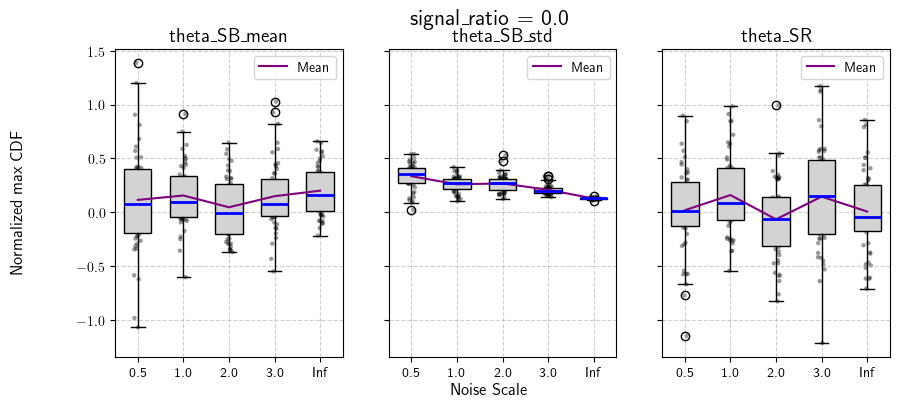

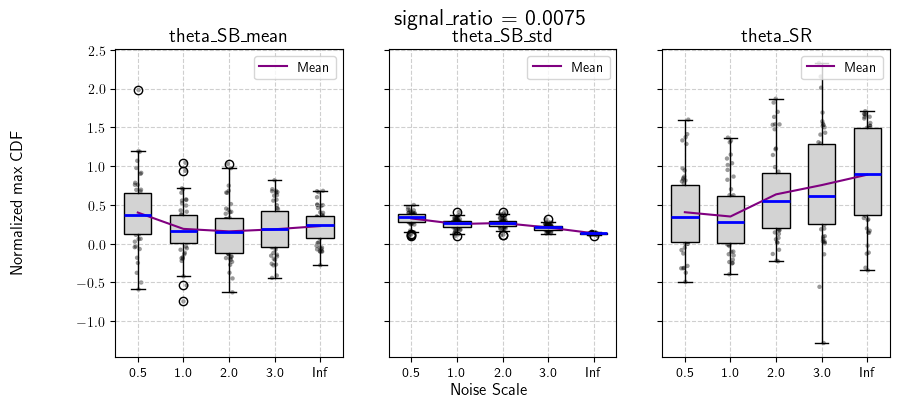

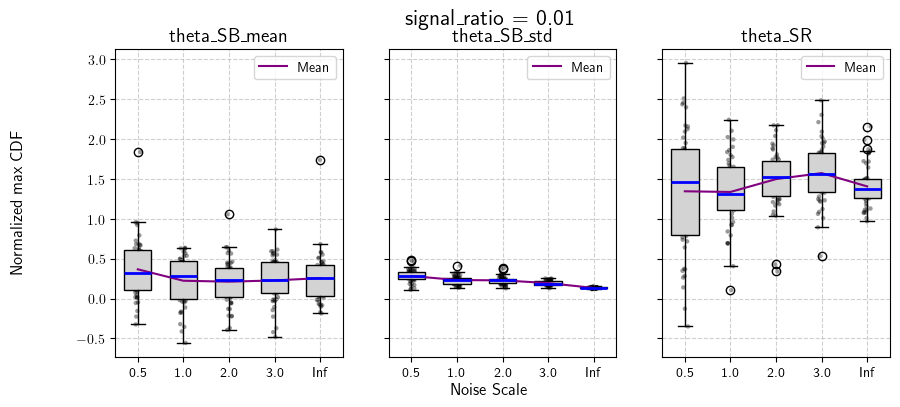

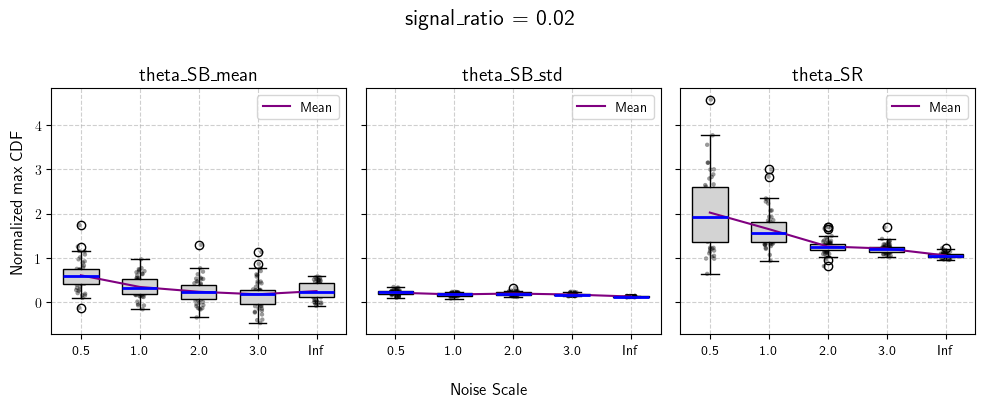

In [9]:
for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    # collect the data for each noise scale
    for i, key in enumerate(["theta_SB_mean", 
                             "theta_SB_std",
                             "theta_SR"]):
        ax = axs[i]
        
        data = []
        for ns in noise_scales:
            group = results_df[1].loc[
                (results_df[1]["signal_ratio"] == signal_ratio) &
                (results_df[1]["noise_scale"] == ns),
                key
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
        
        # ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label=rf"$\alpha$={sig_level}")
            
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(key, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


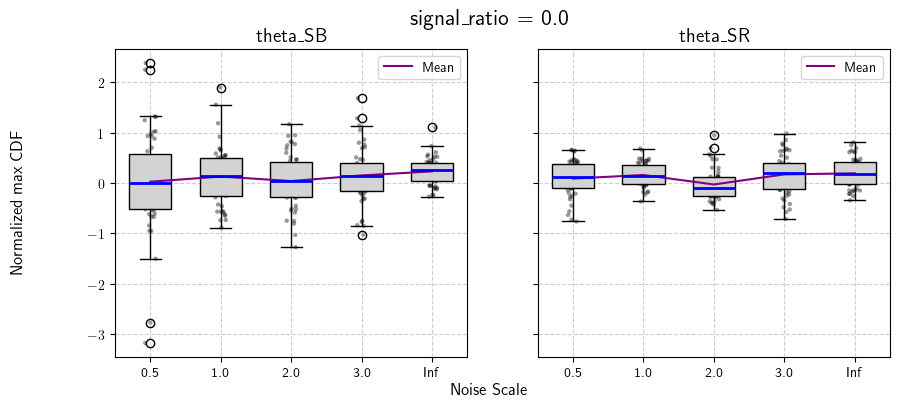

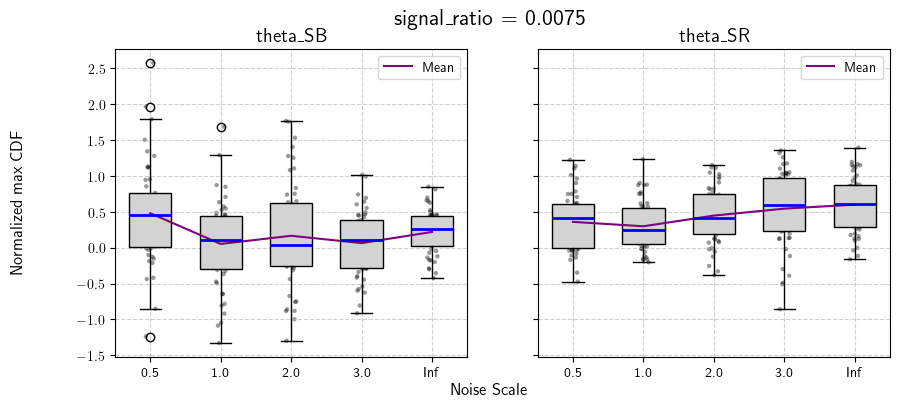

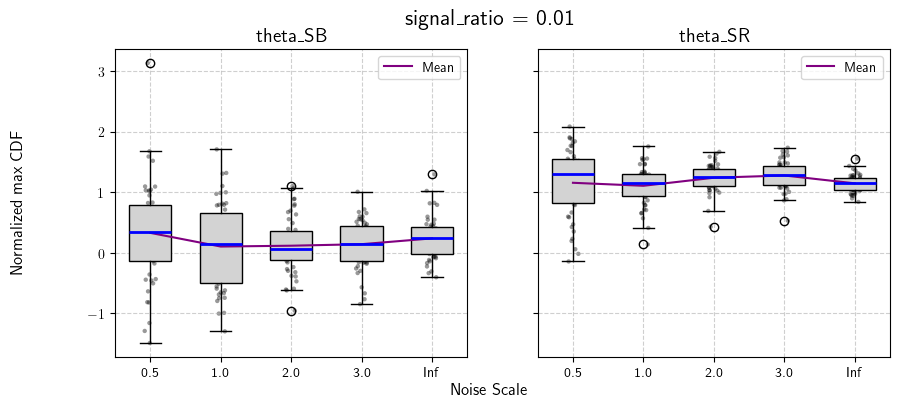

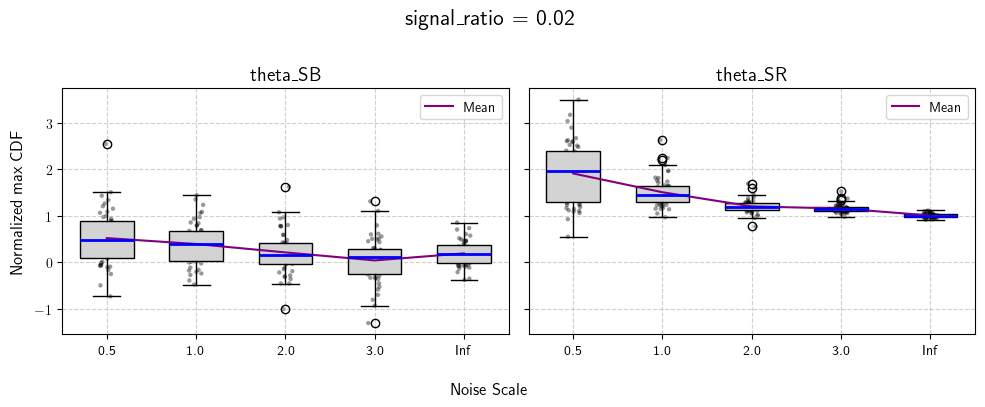

In [17]:
for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    # collect the data for each noise scale
    for i, key in enumerate(["theta_SB", "theta_SR"]):
        ax = axs[i]
        
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["noise_scale"] == ns),
                key
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
            
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(key, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
